<a href="https://colab.research.google.com/github/sona0024/portfolio/blob/main/Netflix_Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Netflix Data**

In [ ]:
# Install necessary packages (only the needed ones)
!pip install pandas matplotlib seaborn scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3  # no need to install separately
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



# Load the dataset
df = pd.read_csv('netflix1.csv')

# Display the first few rows
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('netflix1.csv')

# Display columns
print(df.columns)


Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')


In [ ]:
# Check structure of the dataset
df.info()

# Check for missing values
print(df.isnull().sum())

# Drop duplicates if any
df = df.drop_duplicates()

# Now fill missing values - but only in existing columns
columns_to_fill = ['director', 'country', 'rating', 'date_added', 'duration']

for col in columns_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Special handling if 'cast' column exists
if 'cast' in df.columns:
    df['cast'] = df['cast'].fillna('Unknown')

# Check again if missing values exist
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0


In [ ]:
# How many Movies vs TV Shows
if 'type' in df.columns:
    print(df['type'].value_counts())

# Top 10 countries
if 'country' in df.columns:
    top_countries = df['country'].value_counts().head(10)
    print(top_countries)

# Most common ratings
if 'rating' in df.columns:
    print(df['rating'].value_counts())


type
Movie      6126
TV Show    2664
Name: count, dtype: int64
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


<ipython-input-5-4e5c085ff49f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


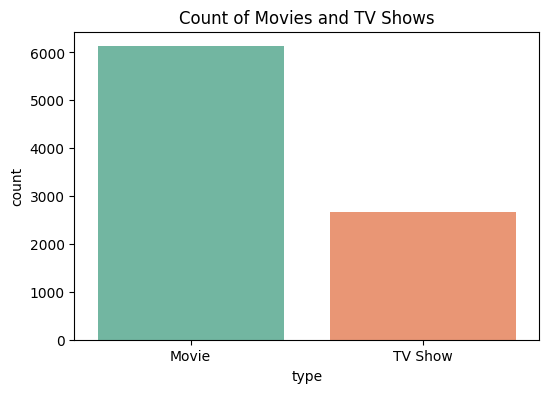

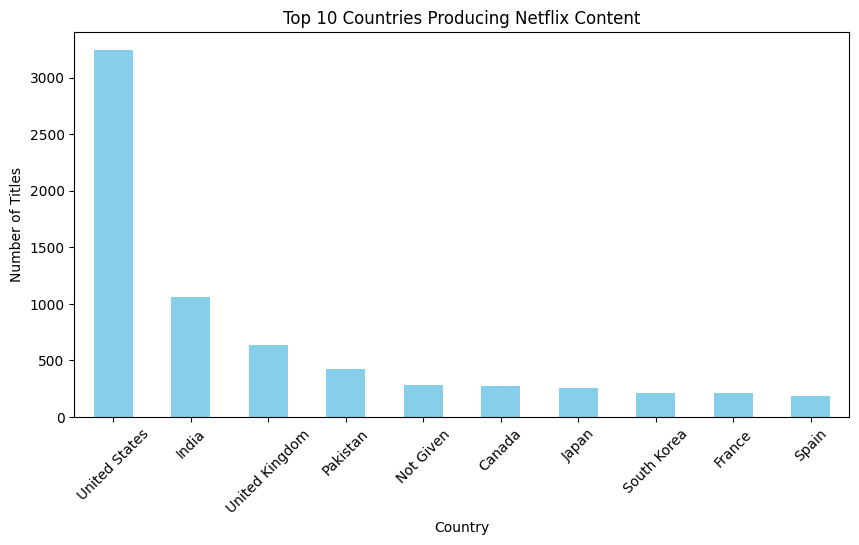

<ipython-input-5-4e5c085ff49f>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')


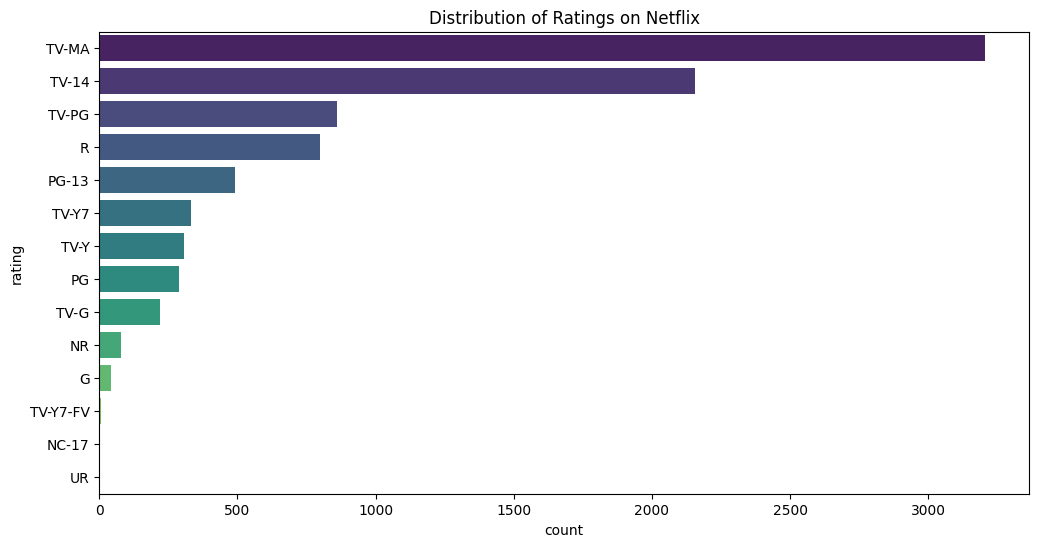

In [ ]:
# Movie vs TV Show Count
if 'type' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='type', palette='Set2')
    plt.title('Count of Movies and TV Shows')
    plt.show()

# Top 10 Countries
if 'country' in df.columns:
    plt.figure(figsize=(10,5))
    df['country'].value_counts().head(10).plot(kind='bar', color='skyblue')
    plt.title('Top 10 Countries Producing Netflix Content')
    plt.xlabel('Country')
    plt.ylabel('Number of Titles')
    plt.xticks(rotation=45)
    plt.show()

# Ratings Distribution
if 'rating' in df.columns:
    plt.figure(figsize=(12,6))
    sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')
    plt.title('Distribution of Ratings on Netflix')
    plt.show()


In [ ]:
# Create a SQLite connection
conn = sqlite3.connect(':memory:')

# Load dataframe to SQLite
df.to_sql('netflix', conn, index=False, if_exists='replace')

# Query 1: Count of each type
query1 = pd.read_sql_query("SELECT type, COUNT(*) as count FROM netflix GROUP BY type", conn)
print(query1)

# Query 2: Top countries
query2 = pd.read_sql_query("SELECT country, COUNT(*) as count FROM netflix GROUP BY country ORDER BY count DESC LIMIT 10", conn)
print(query2)

# Query 3: Titles released after 2015
query3 = pd.read_sql_query("SELECT title, release_year FROM netflix WHERE release_year >= 2015", conn)
print(query3.head())


      type  count
0    Movie   6126
1  TV Show   2664
          country  count
0   United States   3240
1           India   1057
2  United Kingdom    638
3        Pakistan    421
4       Not Given    287
5          Canada    271
6           Japan    259
7     South Korea    214
8          France    213
9           Spain    182
                              title  release_year
0              Dick Johnson Is Dead          2020
1                         Ganglands          2021
2                     Midnight Mass          2021
3  Confessions of an Invisible Girl          2021
4     The Great British Baking Show          2021


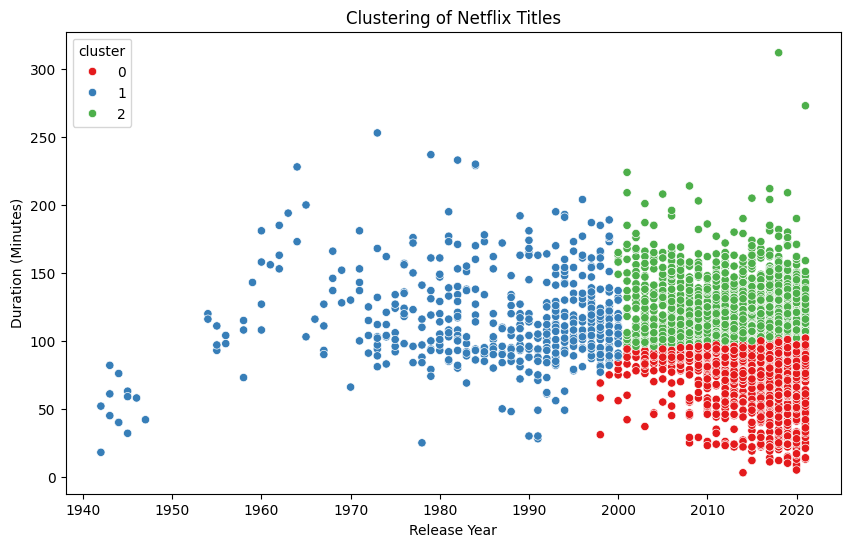

In [ ]:
# (1) Import missing libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# (2) Extract numeric duration
def extract_duration(x):
    if isinstance(x, str) and 'min' in x:
        return int(x.split(' ')[0])
    else:
        return np.nan

if 'duration' in df.columns:
    df['duration_minutes'] = df['duration'].apply(extract_duration)

# (3) Prepare data for clustering
if 'duration_minutes' in df.columns and 'release_year' in df.columns:
    ml_df = df[['release_year', 'duration_minutes']].dropna()

    # (4) Scale features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(ml_df)

    # (5) Apply KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(scaled_features)
    ml_df['cluster'] = kmeans.labels_

    # (6) Visualize clusters
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10,6))
    sns.scatterplot(data=ml_df, x='release_year', y='duration_minutes', hue='cluster', palette='Set1')
    plt.title('Clustering of Netflix Titles')
    plt.xlabel('Release Year')
    plt.ylabel('Duration (Minutes)')
    plt.show()


In [ ]:
# Save the cleaned dataframe to Excel

# Important: openpyxl must be installed (we already installed it before using pip install openpyxl)

output_path = 'netflix_data.xlsx'  # file will be saved here

# Save
df.to_excel(output_path, index=False)

print(f"✅ Cleaned dataset saved successfully at {output_path}!")


✅ Cleaned dataset saved successfully at netflix_data.xlsx!


In [ ]:
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Netflix_Cleaned_Data', index=False)

print(f"✅ Cleaned dataset with sheet name 'Netflix_Cleaned_Data' saved successfully!")


✅ Cleaned dataset with sheet name 'Netflix_Cleaned_Data' saved successfully!
